# Clasificación de textos según los Objetivos de Desarrollo Sostenible

## Objetivo y alcance

Este notebook desarrolla una solución reproducible de procesamiento de lenguaje natural para asociar textos en español con los Objetivos de Desarrollo Sostenible (ODS). El análisis comprende cuatro etapas:

1. preparación de los textos mediante bolsa de palabras ponderada con TF-IDF dentro de un pipeline;
2. construcción de un modelo LSA con `TruncatedSVD` e interpretación cualitativa de sus tópicos;
3. comparación y optimización de modelos de clasificación con reducción de dimensionalidad;
4. evaluación final sobre textos que no participaron en el aprendizaje.

El archivo suministrado contiene únicamente etiquetas ODS 1 a 16. Por tanto, los resultados no pueden extrapolarse al ODS 17.

## 1. Configuración reproducible

Las rutas son relativas al proyecto y se fija una semilla. TF-IDF, SVD y el clasificador se ajustan dentro de pipelines cuando intervienen en validación, evitando fuga de información.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, Normalizer
from sklearn.svm import LinearSVC

from src.text_processing import clean_corpus

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "_94f47dfe96414485b5def55bccbd7cb8_Datos_textosODS.xlsx"
SPLIT_PATH = PROJECT_ROOT / "data" / "particion_train_test.csv"
assert DATA_PATH.exists() and SPLIT_PATH.exists()
print(f"Semilla: {SEED} | Datos: {DATA_PATH.name}")

Semilla: 42 | Datos: _94f47dfe96414485b5def55bccbd7cb8_Datos_textosODS.xlsx


## 2. Datos, auditoría esencial y partición

La partición 80/20 fue construida previamente de forma estratificada y manteniendo en el mismo lado los grupos de textos con similitud aproximada alta. Aquí se carga su manifiesto reproducible. El conjunto de prueba permanecerá aislado hasta cerrar la selección de hiperparámetros.

In [2]:
df = pd.read_excel(DATA_PATH)
split = pd.read_csv(SPLIT_PATH).set_index("row_id")

assert {"textos", "ODS"}.issubset(df.columns)
assert len(df) == len(split)
assert np.array_equal(df["ODS"].to_numpy(), split.loc[df.index, "ODS"].to_numpy())

df = df.join(split[["grupo_similitud", "particion"]])
train_idx = df.index[df["particion"].eq("train")]
test_idx = df.index[df["particion"].eq("test")]

X_train, y_train = df.loc[train_idx, "textos"], df.loc[train_idx, "ODS"]
X_test, y_test = df.loc[test_idx, "textos"], df.loc[test_idx, "ODS"]
grupos_train = df.loc[train_idx, "grupo_similitud"].to_numpy()

resumen = pd.Series({
    "filas": len(df),
    "textos_nulos": df["textos"].isna().sum(),
    "etiquetas_nulas": df["ODS"].isna().sum(),
    "duplicados_exactos": df["textos"].duplicated().sum(),
    "clases": df["ODS"].nunique(),
    "entrenamiento": len(X_train),
    "prueba": len(X_test),
}, name="valor")
display(resumen.to_frame())
print("ODS presentes:", sorted(df["ODS"].unique()))
print("ODS ausente:", sorted(set(range(1, 18)) - set(df["ODS"].unique())))

,valor
filas,9656
textos_nulos,0
etiquetas_nulas,0
duplicados_exactos,0
clases,16
entrenamiento,7724
prueba,1932


ODS presentes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
ODS ausente: [17]


,cantidad,porcentaje
ODS,,
1,505,5.23
2,369,3.82
3,894,9.26
4,1025,10.62
5,1070,11.08
6,695,7.20
7,787,8.15
8,446,4.62
9,343,3.55


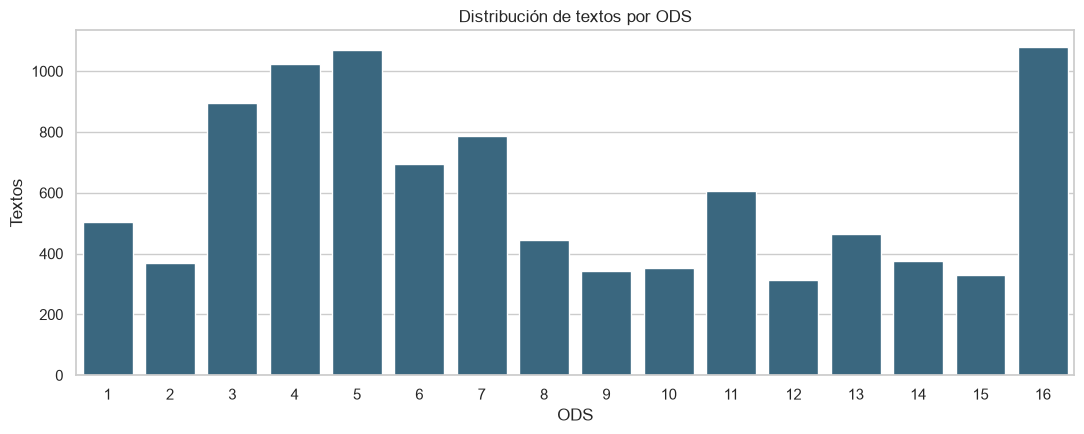

In [3]:
conteo_ods = df["ODS"].value_counts().sort_index()
distribucion = pd.DataFrame({
    "cantidad": conteo_ods,
    "porcentaje": (100 * conteo_ods / len(df)).round(2),
})
display(distribucion)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(x=conteo_ods.index.astype(str), y=conteo_ods.values, color="#2F6B8A", ax=ax)
ax.set(title="Distribución de textos por ODS", xlabel="ODS", ylabel="Textos")
plt.tight_layout()
plt.show()

### Decisiones de preparación

- Se reemplazan URLs y se normalizan espacios, conservando tildes y la letra ñ.
- Se utiliza TF-IDF con frecuencia sublineal; `min_df`, `max_df` y el uso de bigramas se incluyen en la búsqueda.
- No se aplica lematización ni una lista manual de *stopwords*: podrían borrar términos discriminantes y añadir complejidad sin evidencia previa de mejora.
- La desigualdad de tamaños entre clases motiva usar **F1 macro** como criterio principal; accuracy y F1 ponderado se reportan como complemento.

In [4]:
PARAMETROS_TFIDF = {
    "lowercase": True,
    "strip_accents": None,
    "ngram_range": (1, 2),
    "min_df": 3,
    "max_df": 0.30,
    "sublinear_tf": True,
    "norm": "l2",
    "dtype": np.float32,
    "token_pattern": r"(?u)\b\w\w+\b",
}

pipeline_tfidf = Pipeline([
    ("limpieza", FunctionTransformer(clean_corpus, validate=False, feature_names_out="one-to-one")),
    ("tfidf", TfidfVectorizer(**PARAMETROS_TFIDF)),
])
X_train_tfidf = pipeline_tfidf.fit_transform(X_train)
terminos_tfidf = pipeline_tfidf.named_steps["tfidf"].get_feature_names_out()

print(f"TF-IDF: {X_train_tfidf.shape[0]:,} textos × {X_train_tfidf.shape[1]:,} términos")
print(f"Densidad: {100 * X_train_tfidf.nnz / np.prod(X_train_tfidf.shape):.4f} %")
print("Textos de prueba usados para ajustar TF-IDF: 0")
assert (X_train_tfidf.getnnz(axis=1) > 0).all()

TF-IDF: 7,724 textos × 49,511 términos
Densidad: 0.2323 %
Textos de prueba usados para ajustar TF-IDF: 0


## 3. Modelo LSA e interpretación de tópicos

LSA aproxima la matriz TF-IDF mediante SVD truncado. Se exploran 10, 15 y 20 componentes para mantener una representación reducida e interpretable. Se seleccionan 15 como compromiso entre variedad temática, claridad y dimensión.

In [5]:
componentes_candidatos = [10, 15, 20]
modelos_lsa = {}
comparacion_lsa = []

for n in componentes_candidatos:
    modelo = TruncatedSVD(n_components=n, n_iter=10, random_state=SEED)
    modelo.fit(X_train_tfidf)
    modelos_lsa[n] = modelo
    comparacion_lsa.append({
        "componentes": n,
        "varianza_explicada_pct": 100 * modelo.explained_variance_ratio_.sum(),
    })

comparacion_lsa = pd.DataFrame(comparacion_lsa).set_index("componentes")
display(comparacion_lsa.round(3))

lsa = modelos_lsa[15]
X_train_lsa = lsa.transform(X_train_tfidf)
print(f"Reducción para tópicos: {X_train_tfidf.shape[1]:,} → {X_train_lsa.shape[1]} dimensiones")

,varianza_explicada_pct
componentes,
10,1.956
15,2.586
20,3.117


Reducción para tópicos: 49,511 → 15 dimensiones


,términos con mayor loading,ODS frecuentes en 30 textos
componente,,
2,"derechos, derecho, derechos humanos, humanos, ...",ODS 16: 30
3,"mujeres, las mujeres, género, de género, hombr...","ODS 5: 29, ODS 10: 1"
4,"educación, estudiantes, escuelas, salud, atenc...","ODS 4: 15, ODS 3: 15"
6,"salud, atención, de salud, servicios, agua, la...",ODS 3: 30
7,"agua, de agua, del agua, aguas, de aguas, estu...","ODS 6: 28, ODS 2: 1, ODS 15: 1"
8,"energía, de energía, electricidad, la energía,...",ODS 7: 30
12,"pobreza, climático, niños, energía, mujeres, c...","ODS 13: 19, ODS 1: 8, ODS 5: 3"
14,"derechos, educación, países, los países, desar...","ODS 2: 14, ODS 9: 3, ODS 16: 3, ODS 1: 3"


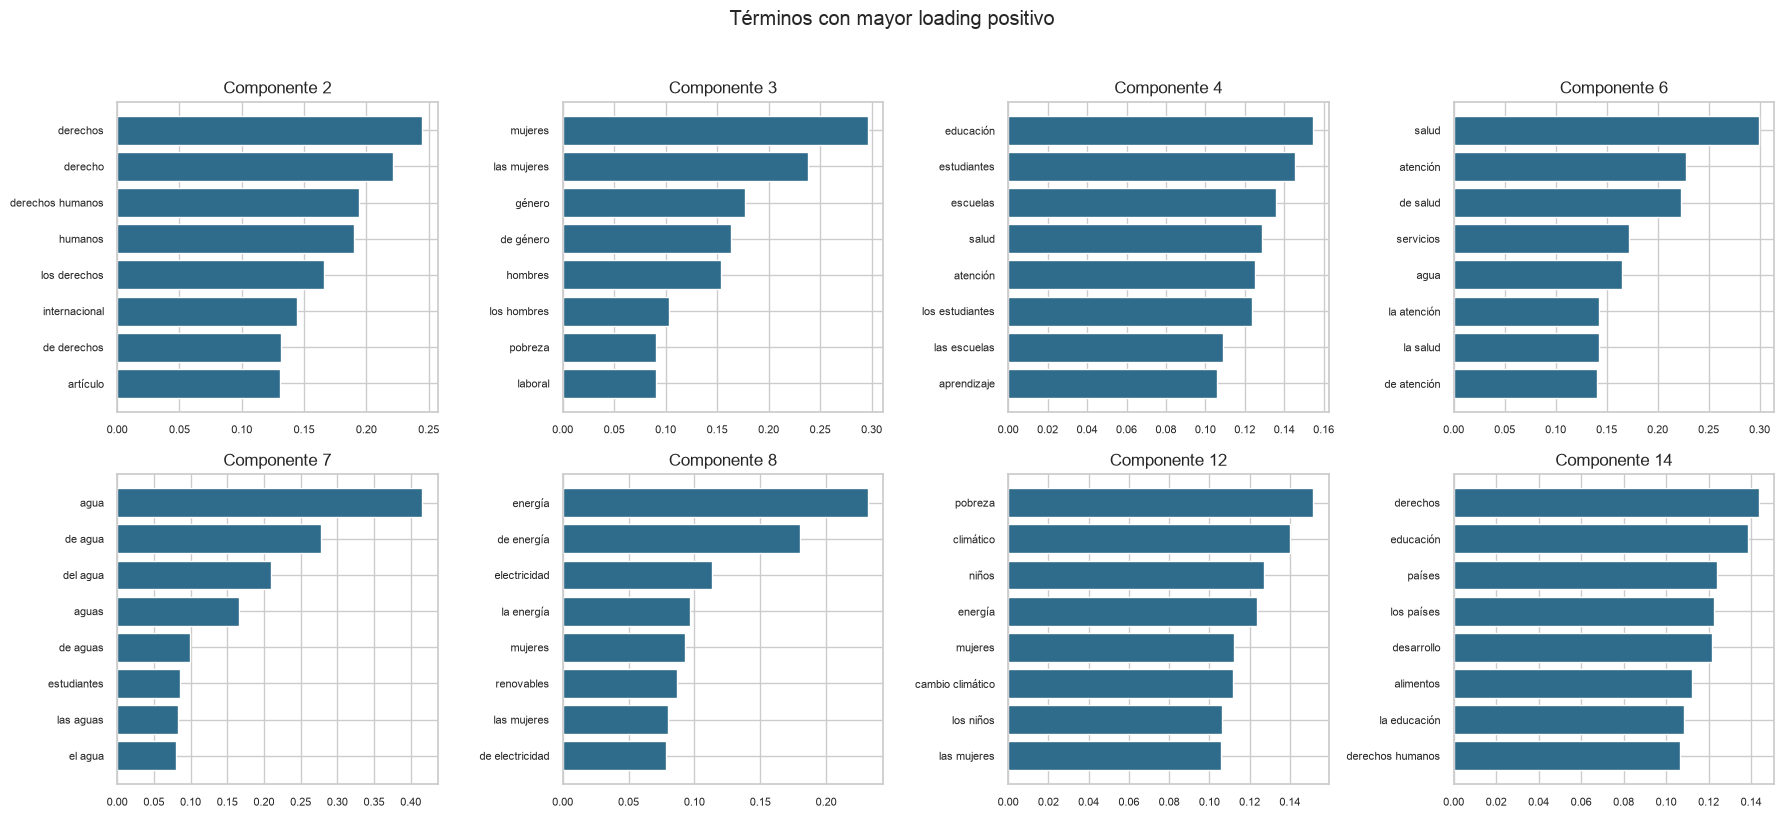

In [6]:
componentes_interpretados = [2, 3, 4, 6, 7, 8, 12, 14]
filas = []

for componente in componentes_interpretados:
    i = componente - 1
    top_terminos = np.argsort(lsa.components_[i])[-12:][::-1]
    top_documentos = np.argsort(X_train_lsa[:, i])[-30:][::-1]
    etiquetas = y_train.iloc[top_documentos].value_counts()
    filas.append({
        "componente": componente,
        "términos con mayor loading": ", ".join(terminos_tfidf[top_terminos]),
        "ODS frecuentes en 30 textos": ", ".join(
            f"ODS {ods}: {n}" for ods, n in etiquetas.head(4).items()
        ),
    })

tabla_topicos = pd.DataFrame(filas).set_index("componente")
display(tabla_topicos)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for componente, ax in zip(componentes_interpretados, axes.flat):
    pesos = lsa.components_[componente - 1]
    idx = np.argsort(pesos)[-8:]
    ax.barh(terminos_tfidf[idx], pesos[idx], color="#2F6B8A")
    ax.set_title(f"Componente {componente}")
    ax.tick_params(labelsize=8)
plt.suptitle("Términos con mayor loading positivo", y=1.02)
plt.tight_layout()
plt.show()

### Interpretación cualitativa de ocho tópicos

| Componente | Interpretación | Relación con los ODS |
|---:|---|---|
| 2 | Derechos humanos, legislación e instituciones | ODS 16: Paz, justicia e instituciones sólidas. |
| 3 | Igualdad de género y brechas laborales | Principalmente ODS 5; cercanía secundaria con ODS 8 y 10. |
| 4 | Educación y salud como servicios sociales | Mezcla coherente de ODS 4 y ODS 3. |
| 6 | Sistemas y atención sanitaria | ODS 3: Salud y bienestar. |
| 7 | Agua, saneamiento y gestión hídrica | ODS 6: Agua limpia y saneamiento. |
| 8 | Electricidad y transición energética | ODS 7: Energía asequible y no contaminante. |
| 12 | Impactos climáticos, pobreza y vulnerabilidad | Relaciona ODS 13 con ODS 1. |
| 14 | Seguridad alimentaria, producción y acceso | Principalmente ODS 2: Hambre cero. |

Los componentes no equivalen necesariamente a una etiqueta. LSA es no supervisado y captura ejes semánticos compartidos; los componentes mixtos reflejan relaciones reales entre objetivos. La varianza explicada es moderada porque el vocabulario textual es disperso, pero los términos y documentos representativos permiten interpretaciones coherentes.

## 4. Clasificación y selección del modelo

Se comparan una referencia ingenua, regresión logística y SVM lineal. Los dos modelos principales integran TF-IDF, `TruncatedSVD` y normalización dentro del pipeline. SVM lineal es apropiado para representaciones textuales de alta dimensión y permite controlar la regularización mediante `C`; la regresión logística ofrece un contraste lineal interpretable. También se incluye una SVM directa sobre TF-IDF como referencia para cuantificar el efecto predictivo de la reducción SVD.

In [7]:
def pasos_texto():
    return [
        ("limpieza", FunctionTransformer(clean_corpus, validate=False, feature_names_out="one-to-one")),
        ("tfidf", TfidfVectorizer(**PARAMETROS_TFIDF)),
    ]

def entrada_dummy(corpus):
    return np.zeros((len(corpus), 1), dtype=np.float32)

pipeline_dummy = Pipeline([
    ("entrada", FunctionTransformer(entrada_dummy, validate=False)),
    ("clasificador", DummyClassifier(strategy="most_frequent")),
])
pipeline_logistica = Pipeline(pasos_texto() + [
    ("svd", TruncatedSVD(n_components=100, n_iter=7, random_state=SEED)),
    ("normalizacion", Normalizer(copy=False)),
    ("clasificador", LogisticRegression(C=1, class_weight="balanced", max_iter=2000, random_state=SEED)),
])
pipeline_svm_svd = Pipeline(pasos_texto() + [
    ("svd", TruncatedSVD(n_components=100, n_iter=7, random_state=SEED)),
    ("normalizacion", Normalizer(copy=False)),
    ("clasificador", LinearSVC(C=1, class_weight="balanced", random_state=SEED)),
])
pipeline_svm_directa = Pipeline(pasos_texto() + [
    ("clasificador", LinearSVC(C=1, class_weight="balanced", random_state=SEED)),
])

modelos = {
    "Dummy mayoritaria": pipeline_dummy,
    "Logística + SVD(100)": pipeline_logistica,
    "SVM + SVD(100)": pipeline_svm_svd,
    "SVM + TF-IDF directo (referencia)": pipeline_svm_directa,
}

cv_3 = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
splits_3 = list(cv_3.split(X_train, y_train, grupos_train))
metricas_cv = {"accuracy": "accuracy", "f1_macro": "f1_macro", "f1_weighted": "f1_weighted"}

,accuracy,f1_macro,f1_macro_std,f1_weighted
modelo,,,,
SVM + TF-IDF directo (referencia),0.8862,0.8618,0.0011,0.8850
SVM + SVD(100),0.8450,0.8115,0.0045,0.8447
Logística + SVD(100),0.8402,0.8098,0.0058,0.8424
Dummy mayoritaria,0.1119,0.0126,0.0000,0.0225


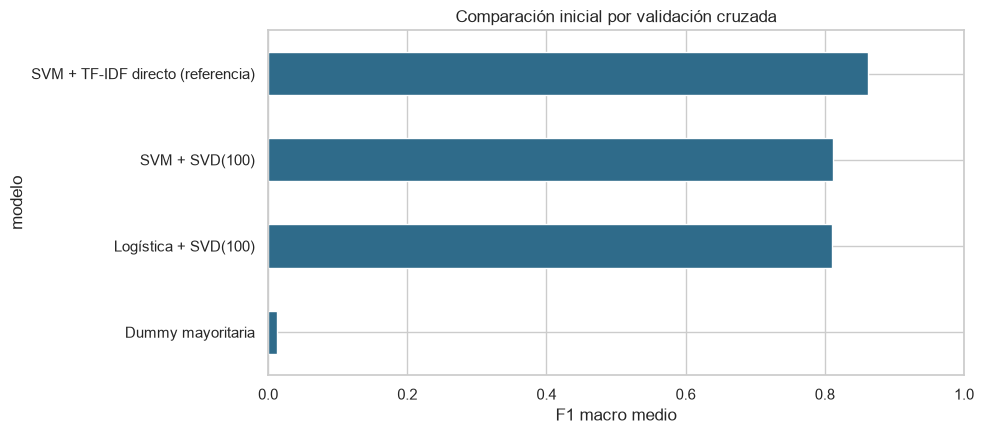

In [8]:
resultados_candidatos = []
for nombre, modelo in modelos.items():
    resultado = cross_validate(
        modelo, X_train, y_train, cv=splits_3, scoring=metricas_cv,
        n_jobs=1, return_train_score=False, error_score="raise",
    )
    resultados_candidatos.append({
        "modelo": nombre,
        "accuracy": resultado["test_accuracy"].mean(),
        "f1_macro": resultado["test_f1_macro"].mean(),
        "f1_macro_std": resultado["test_f1_macro"].std(),
        "f1_weighted": resultado["test_f1_weighted"].mean(),
    })

comparacion_modelos = (
    pd.DataFrame(resultados_candidatos).set_index("modelo").sort_values("f1_macro", ascending=False)
)
display(comparacion_modelos.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
comparacion_modelos.sort_values("f1_macro")["f1_macro"].plot.barh(color="#2F6B8A", ax=ax)
ax.set(title="Comparación inicial por validación cruzada", xlabel="F1 macro medio", xlim=(0, 1))
plt.tight_layout()
plt.show()

La comparación inicial selecciona **SVM lineal con SVD** como candidato reducido. La SVM directa se conserva como referencia. A continuación se optimizan conjuntamente la representación, la dimensión y la regularización mediante cinco folds estratificados por grupos. Así se evita que versiones similares de un texto aparezcan simultáneamente en ajuste y validación.

In [9]:
cv_5 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
splits_5 = list(cv_5.split(X_train, y_train, grupos_train))

auditoria_folds = []
for fold, (ajuste, validacion) in enumerate(splits_5, start=1):
    ga, gv = set(grupos_train[ajuste]), set(grupos_train[validacion])
    auditoria_folds.append({
        "fold": fold,
        "n_ajuste": len(ajuste),
        "n_validacion": len(validacion),
        "grupos_compartidos": len(ga & gv),
        "clases_validacion": y_train.iloc[validacion].nunique(),
    })

auditoria_folds = pd.DataFrame(auditoria_folds).set_index("fold")
display(auditoria_folds)
assert auditoria_folds["grupos_compartidos"].eq(0).all()
assert auditoria_folds["clases_validacion"].eq(16).all()

,n_ajuste,n_validacion,grupos_compartidos,clases_validacion
fold,,,,
1,6179,1545,0,16
2,6179,1545,0,16
3,6179,1545,0,16
4,6180,1544,0,16
5,6179,1545,0,16


In [10]:
configuraciones = [
    {"svd__n_components": 100, "clasificador__C": 1.0, "clasificador__class_weight": "balanced", "tfidf__min_df": 3, "tfidf__max_df": .30, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 200, "clasificador__C": 1.0, "clasificador__class_weight": "balanced", "tfidf__min_df": 3, "tfidf__max_df": .30, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 300, "clasificador__C": 1.0, "clasificador__class_weight": "balanced", "tfidf__min_df": 3, "tfidf__max_df": .30, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 200, "clasificador__C": .5, "clasificador__class_weight": "balanced", "tfidf__min_df": 3, "tfidf__max_df": .30, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 200, "clasificador__C": 2.0, "clasificador__class_weight": "balanced", "tfidf__min_df": 3, "tfidf__max_df": .30, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 300, "clasificador__C": .5, "clasificador__class_weight": "balanced", "tfidf__min_df": 3, "tfidf__max_df": .30, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 300, "clasificador__C": 2.0, "clasificador__class_weight": "balanced", "tfidf__min_df": 3, "tfidf__max_df": .30, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 200, "clasificador__C": 1.0, "clasificador__class_weight": None, "tfidf__min_df": 3, "tfidf__max_df": .30, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 300, "clasificador__C": 1.0, "clasificador__class_weight": None, "tfidf__min_df": 3, "tfidf__max_df": .30, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 300, "clasificador__C": 1.0, "clasificador__class_weight": "balanced", "tfidf__min_df": 2, "tfidf__max_df": .50, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 300, "clasificador__C": 1.0, "clasificador__class_weight": "balanced", "tfidf__min_df": 5, "tfidf__max_df": .50, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 300, "clasificador__C": 1.0, "clasificador__class_weight": "balanced", "tfidf__min_df": 3, "tfidf__max_df": .80, "tfidf__ngram_range": (1, 1)},
]
param_grid = [{k: [v] for k, v in c.items()} for c in configuraciones]
display(pd.DataFrame(configuraciones))
print(f"12 configuraciones × 5 folds = 60 ajustes, más el reajuste final.")

,svd__n_components,clasificador__C,clasificador__class_weight,tfidf__min_df,tfidf__max_df,tfidf__ngram_range
0,100,1.0,balanced,3,0.3,"(1, 2)"
1,200,1.0,balanced,3,0.3,"(1, 2)"
2,300,1.0,balanced,3,0.3,"(1, 2)"
3,200,0.5,balanced,3,0.3,"(1, 2)"
4,200,2.0,balanced,3,0.3,"(1, 2)"
5,300,0.5,balanced,3,0.3,"(1, 2)"
6,300,2.0,balanced,3,0.3,"(1, 2)"
7,200,1.0,NaN,3,0.3,"(1, 2)"
8,300,1.0,NaN,3,0.3,"(1, 2)"
9,300,1.0,balanced,2,0.5,"(1, 2)"


12 configuraciones × 5 folds = 60 ajustes, más el reajuste final.


In [11]:
busqueda = GridSearchCV(
    estimator=clone(pipeline_svm_svd),
    param_grid=param_grid,
    scoring=metricas_cv,
    refit="f1_macro",
    cv=splits_5,
    n_jobs=1,
    return_train_score=False,
    error_score="raise",
)
busqueda.fit(X_train, y_train)

print(f"Mejor F1 macro CV: {busqueda.best_score_:.4f}")
print("Mejores hiperparámetros:")
for nombre, valor in busqueda.best_params_.items():
    print(f"- {nombre}: {valor}")

Mejor F1 macro CV: 0.8354
Mejores hiperparámetros:
- clasificador__C: 0.5
- clasificador__class_weight: balanced
- svd__n_components: 300
- tfidf__max_df: 0.3
- tfidf__min_df: 3
- tfidf__ngram_range: (1, 2)


In [12]:
resultados_busqueda = pd.DataFrame(busqueda.cv_results_)
columnas = [
    "rank_test_f1_macro", "mean_test_f1_macro", "std_test_f1_macro",
    "mean_test_accuracy", "mean_test_f1_weighted",
    "param_svd__n_components", "param_clasificador__C",
    "param_clasificador__class_weight", "param_tfidf__min_df",
    "param_tfidf__max_df", "param_tfidf__ngram_range",
]
ranking = resultados_busqueda[columnas].sort_values("rank_test_f1_macro")
display(ranking.round(4))

,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_test_accuracy,mean_test_f1_weighted,param_svd__n_components,param_clasificador__C,param_clasificador__class_weight,param_tfidf__min_df,param_tfidf__max_df,param_tfidf__ngram_range
5,1,0.8354,0.0147,0.8648,0.8641,300,0.5,balanced,3,0.3,"(1, 2)"
11,2,0.8324,0.0119,0.8611,0.8604,300,1.0,balanced,3,0.8,"(1, 1)"
2,3,0.8301,0.0127,0.8612,0.8604,300,1.0,balanced,3,0.3,"(1, 2)"
8,4,0.8299,0.0133,0.8615,0.8594,300,1.0,NaN,3,0.3,"(1, 2)"
9,5,0.8285,0.0137,0.8597,0.8587,300,1.0,balanced,2,0.5,"(1, 2)"
3,6,0.8261,0.0145,0.8569,0.8565,200,0.5,balanced,3,0.3,"(1, 2)"
7,7,0.8253,0.0117,0.8578,0.8558,200,1.0,NaN,3,0.3,"(1, 2)"
10,8,0.8242,0.0118,0.8563,0.8556,300,1.0,balanced,5,0.5,"(1, 2)"
1,9,0.8242,0.0142,0.8554,0.8548,200,1.0,balanced,3,0.3,"(1, 2)"
6,10,0.8205,0.0112,0.8533,0.8524,300,2.0,balanced,3,0.3,"(1, 2)"


### Selección final antes de consultar prueba

La búsqueda seleccionó TF-IDF con unigramas y bigramas (`min_df=3`, `max_df=0,30`), SVD con 300 componentes, normalización y `LinearSVC(C=0,5, class_weight="balanced")`. El mejor F1 macro medio fue **0,8354**.

El aumento de componentes conserva más estructura semántica, mientras que la regularización seleccionada limita el sobreajuste. Los pesos balanceados compensan parcialmente la diferencia de frecuencia entre ODS. Toda la selección se realizó mediante cinco folds sobre entrenamiento; el conjunto de prueba permaneció aislado hasta la sección siguiente.

## 5. Evaluación final sobre textos no vistos

Se reajusta el pipeline seleccionado con todo el conjunto de entrenamiento. Se reportan accuracy, F1 macro y F1 ponderado. F1 macro es la medida principal porque pondera por igual los 16 ODS, incluidos los menos frecuentes.

In [13]:
pipeline_final = clone(busqueda.best_estimator_)
pipeline_final.fit(X_train, y_train)

y_pred_test = pipeline_final.predict(X_test)
puntajes_test = pipeline_final.decision_function(X_test)

metricas_test = pd.Series({
    "accuracy": accuracy_score(y_test, y_pred_test),
    "f1_macro": f1_score(y_test, y_pred_test, average="macro"),
    "f1_weighted": f1_score(y_test, y_pred_test, average="weighted"),
    "n_test": len(y_test),
}, name="prueba")

comparacion_cv_test = pd.DataFrame({
    "validación_cruzada": [
        resultados_busqueda.loc[busqueda.best_index_, "mean_test_accuracy"],
        busqueda.best_score_,
        resultados_busqueda.loc[busqueda.best_index_, "mean_test_f1_weighted"],
    ],
    "prueba_final": [
        metricas_test["accuracy"], metricas_test["f1_macro"], metricas_test["f1_weighted"],
    ],
}, index=["accuracy", "f1_macro", "f1_weighted"])
display(comparacion_cv_test.round(4))

,validación_cruzada,prueba_final
accuracy,0.8648,0.8727
f1_macro,0.8354,0.8406
f1_weighted,0.8641,0.8727


,precision,recall,f1-score,support
1,0.837,0.812,0.824,101.0
2,0.795,0.838,0.816,74.0
3,0.922,0.922,0.922,179.0
4,0.957,0.976,0.966,205.0
5,0.953,0.939,0.946,214.0
6,0.928,0.921,0.924,139.0
7,0.894,0.911,0.903,158.0
8,0.602,0.629,0.615,89.0
9,0.718,0.739,0.729,69.0
10,0.667,0.657,0.662,70.0


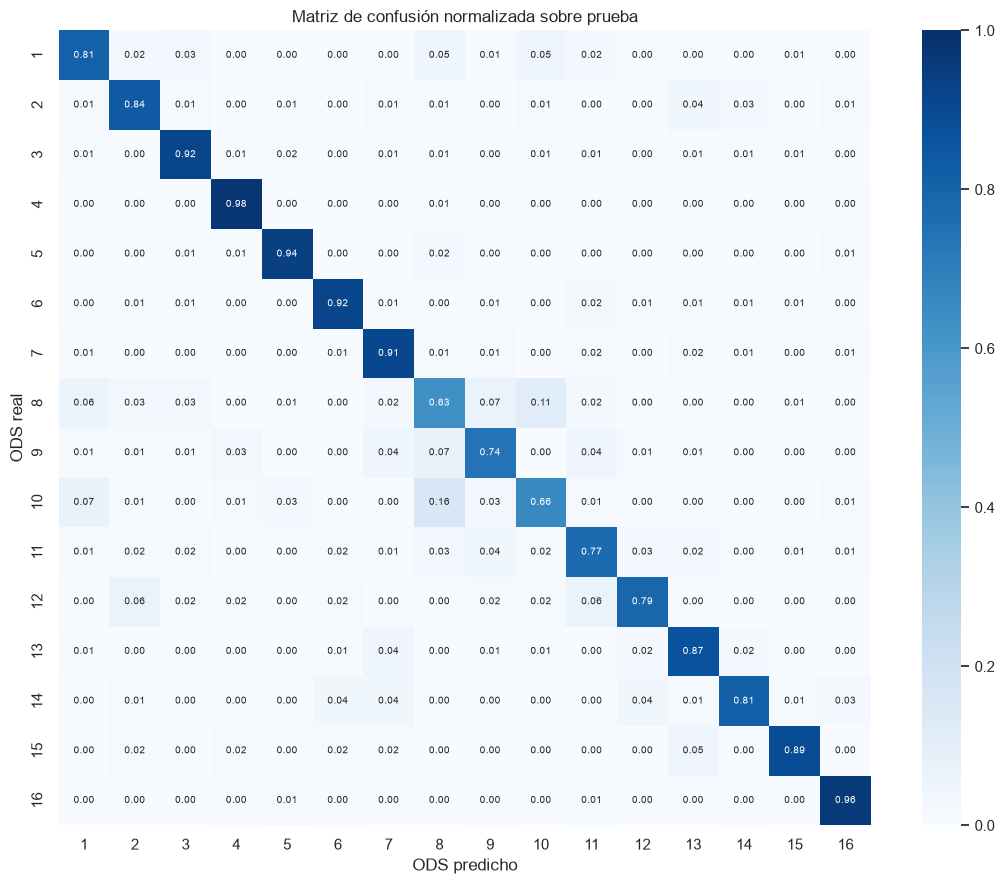

In [14]:
etiquetas = sorted(df["ODS"].unique())
reporte = pd.DataFrame(classification_report(
    y_test, y_pred_test, labels=etiquetas, output_dict=True, zero_division=0,
)).T
display(reporte.loc[[str(i) for i in etiquetas]].round(3))

matriz_norm = confusion_matrix(y_test, y_pred_test, labels=etiquetas, normalize="true")
matriz_abs = confusion_matrix(y_test, y_pred_test, labels=etiquetas)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    matriz_norm, cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".2f",
    xticklabels=etiquetas, yticklabels=etiquetas, annot_kws={"size": 7}, ax=ax,
)
ax.set(title="Matriz de confusión normalizada sobre prueba", xlabel="ODS predicho", ylabel="ODS real")
plt.tight_layout()
plt.show()

### Ejemplos de clasificación sobre el conjunto de prueba

Se presentan ocho casos de clases diversas: cuatro aciertos y cuatro errores. Esta combinación permite observar tanto el desempeño esperado como las confusiones que persisten. El margen es la diferencia entre los dos puntajes más altos de la SVM; **no es una probabilidad**.

In [15]:
NOMBRES_ODS = {
    1: "Fin de la pobreza", 2: "Hambre cero", 3: "Salud y bienestar",
    4: "Educación de calidad", 5: "Igualdad de género", 6: "Agua limpia y saneamiento",
    7: "Energía asequible y no contaminante", 8: "Trabajo decente y crecimiento económico",
    9: "Industria, innovación e infraestructura", 10: "Reducción de las desigualdades",
    11: "Ciudades y comunidades sostenibles", 12: "Producción y consumo responsables",
    13: "Acción por el clima", 14: "Vida submarina", 15: "Vida de ecosistemas terrestres",
    16: "Paz, justicia e instituciones sólidas",
}

clases = pipeline_final.named_steps["clasificador"].classes_
orden = np.argsort(puntajes_test, axis=1)[:, ::-1]
margen = (
    np.take_along_axis(puntajes_test, orden[:, :1], axis=1).ravel()
    - np.take_along_axis(puntajes_test, orden[:, 1:2], axis=1).ravel()
)

resultados = pd.DataFrame({
    "row_id": X_test.index,
    "ODS_real": y_test.to_numpy(),
    "ODS_predicho": y_pred_test,
    "correcta": y_test.to_numpy() == y_pred_test,
    "margen": margen,
    "texto": X_test.to_numpy(),
})
resultados["top_3"] = [
    ", ".join(f"ODS {int(clases[j])} ({puntajes_test[i, j]:.3f})" for j in orden[i, :3])
    for i in range(len(resultados))
]

aciertos = resultados[resultados["correcta"]].sort_values("margen", ascending=False).groupby("ODS_real").head(1).head(4)
errores = resultados[~resultados["correcta"]].sort_values("margen", ascending=False).groupby("ODS_real").head(1).head(4)
ejemplos = pd.concat([aciertos, errores], ignore_index=True)
ejemplos["ODS_real_nombre"] = ejemplos["ODS_real"].map(NOMBRES_ODS)
ejemplos["ODS_predicho_nombre"] = ejemplos["ODS_predicho"].map(NOMBRES_ODS)
ejemplos["texto"] = ejemplos["texto"].str.replace(r"\s+", " ", regex=True).str.slice(0, 450)

display(ejemplos[[
    "row_id", "ODS_real", "ODS_real_nombre", "ODS_predicho", "ODS_predicho_nombre",
    "correcta", "margen", "top_3", "texto",
]].round({"margen": 3}))

,row_id,ODS_real,ODS_real_nombre,ODS_predicho,ODS_predicho_nombre,correcta,margen,top_3,texto
0,4358,14,Vida submarina,14,Vida submarina,True,5.609,"ODS 14 (4.291), ODS 7 (-1.319), ODS 5 (-1.341)","La Resolución 49/116, de 19 de diciembre de 19..."
1,2412,7,Energía asequible y no contaminante,7,Energía asequible y no contaminante,True,5.068,"ODS 7 (3.604), ODS 3 (-1.464), ODS 1 (-1.498)","A corto plazo, mientras se mantenga la estruct..."
2,8957,16,"Paz, justicia e instituciones sólidas",16,"Paz, justicia e instituciones sólidas",True,5.028,"ODS 16 (3.598), ODS 6 (-1.430), ODS 1 (-1.514)",El presidente George W. Bush y su gobierno pre...
3,6181,3,Salud y bienestar,3,Salud y bienestar,True,4.736,"ODS 3 (3.302), ODS 1 (-1.435), ODS 6 (-1.467)",Los conjuntos de datos incluidos en este estud...
4,9248,11,Ciudades y comunidades sostenibles,12,Producción y consumo responsables,False,3.623,"ODS 12 (2.771), ODS 14 (-0.852), ODS 6 (-1.197)",Las políticas de gestión y reciclaje de residu...
5,8858,1,Fin de la pobreza,8,Trabajo decente y crecimiento económico,False,2.678,"ODS 8 (1.878), ODS 10 (-0.800), ODS 1 (-0.893)",El crecimiento en el número de autónomos contr...
6,2257,8,Trabajo decente y crecimiento económico,1,Fin de la pobreza,False,2.410,"ODS 1 (1.763), ODS 8 (-0.647), ODS 2 (-0.769)",La visión convencional es insuficiente y poten...
7,4703,10,Reducción de las desigualdades,8,Trabajo decente y crecimiento económico,False,2.264,"ODS 8 (1.306), ODS 11 (-0.958), ODS 5 (-1.027)",La Ley de Promoción del Empleo incluye normas ...


In [16]:
confusiones = []
for i, real in enumerate(etiquetas):
    for j, predicho in enumerate(etiquetas):
        if i != j and matriz_abs[i, j] > 0:
            confusiones.append({
                "ODS_real": real,
                "ODS_predicho": predicho,
                "cantidad": matriz_abs[i, j],
                "porcentaje_clase_real": 100 * matriz_norm[i, j],
            })
display(pd.DataFrame(confusiones).sort_values("cantidad", ascending=False).head(10).round(2))

,ODS_real,ODS_predicho,cantidad,porcentaje_clase_real
74,10,8,11,15.71
58,8,10,10,11.24
57,8,9,6,6.74
70,10,1,5,7.14
2,1,8,5,4.95
4,1,10,5,4.95
32,5,8,5,2.34
66,9,8,5,7.25
84,11,9,5,4.10
52,8,1,5,5.62


## 6. Conclusiones

El pipeline final obtuvo **accuracy 0,8727**, **F1 macro 0,8406** y **F1 ponderado 0,8727** sobre 1.932 textos de prueba. La cercanía con la validación cruzada indica una generalización estable. Los ODS 8, 9 y 10 presentan las mayores dificultades, principalmente por vocabulario compartido sobre empleo, desigualdad, crecimiento e infraestructura.

La representación TF-IDF preservó señales léxicas relevantes y la reducción SVD permitió trabajar con una representación semántica compacta. En el análisis no supervisado, ocho componentes mostraron asociaciones interpretables con objetivos como salud, educación, igualdad de género, agua, energía, acción climática e instituciones. En clasificación, la SVM lineal superó a la regresión logística entre los modelos reducidos y mantuvo resultados consistentes entre validación y prueba.

El análisis de errores muestra que varias confusiones son semánticamente plausibles: trabajo, desigualdad, industria y desarrollo urbano comparten vocabulario económico y social. Una extensión natural sería formular el problema como clasificación multietiqueta o incorporar más datos para las clases con menor desempeño.

**Limitaciones.** No hay ejemplos del ODS 17; los márgenes de `LinearSVC` no son probabilidades calibradas; una etiqueta única simplifica textos que pueden relacionarse con varios ODS. El modelo es adecuado como demostración académica y apoyo exploratorio, no como sustituto de evaluación experta.

## 7. Reproducción y aplicación interactiva

El análisis puede reproducirse ejecutando todas las celdas desde la raíz del proyecto con las dependencias definidas en `requirements.txt`. Las rutas son relativas y la semilla aleatoria permanece fijada.

La aplicación interactiva se inicia con:

```bash
streamlit run app.py
```

La interfaz reutiliza el pipeline serializado para recibir un texto libre y devolver el ODS predicho junto con las alternativas principales.